# Threshold Calibration — v2

Refactor of v1 addressing five design issues raised after running v1 on the
real 68-dict corpus:

1. **Shape-aware threshold derivation.** v1 chose between bimodal valley and
   p75 quantile based on a simple bimodality check. v2 uses a richer shape
   classification (clearly bimodal / strongly skewed / mildly skewed /
   symmetric / degenerate) and selects the threshold method accordingly.
   Symmetric-unimodal distributions get rules **skipped** rather than
   assigned a fixed-quantile threshold — because the data doesn't show the
   structure that would justify one.

2. **Distribution diagnostics added.** Each metric reports dip-test
   p-value, skewness, IQR, and a shape verdict, so threshold choices are
   explicitly grounded in distribution shape rather than picked by rule.

3. **Threshold confidence tagged.** Each rule's threshold is now tagged
   `high` (bimodal valley), `medium` (strongly skewed quantile), `low`
   (mildly skewed quantile), or `low_targeted` (skipped by shape but kept
   because a fix script targets it). Downstream consumers can filter
   accordingly.

4. **Reference-dict widening removed.** v1 widened thresholds to ensure the
   4 reference dicts always passed. v2 removes this — whatever shape-aware
   threshold the data produces is the threshold. Reference-dict status
   under the new threshold is reported as a diagnostic, not used to modify
   the threshold.

5. **Retention rate rules added in parallel.** Three new rules
   (`billex_low_retention`, `morph_low_retention`, `parcor_low_retention`)
   measure `<resource>_rows / prep_rows`. These run alongside the existing
   absolute row-count rules so we can compare which approach
   discriminates better. Retention is marked `not_applicable` for dicts
   with `prep_rows < 100` to avoid spurious results from tiny denominators.

## Outputs (in `../evaluation/calibration_v2/`)

- `_threshold_justifications.csv` — extended with `shape`, `confidence`,
  `dip_pvalue`, `skewness`, `reference_dicts_flagged`
- `_distribution_diagnostics.csv` — per-metric shape diagnostics
- `_retention_vs_rowcount_comparison.csv` — which dicts each rule flags,
  side-by-side
- `_distribution_diagnostics.png` — grid showing every distribution with
  threshold marked and "bad" region shaded
- `_retention_vs_rowcount_comparison.png` — visualization of overlap
  between row-count and retention rules

v1 outputs in `../evaluation/calibration/` are left intact for comparison.

## 1. Imports & paths

In [11]:
import warnings
from pathlib import Path
from typing import Optional

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import diptest

from _common import parse_dict_id, load_direction_lookup, direction_for

DIRS = {
    "prep":   Path("../Ekstraksi/6. Pemecahan Definisi Lema"),
    "billex": Path("../Ekstraksi/9. Bilingual Lexicon"),
    "morph":  Path("../Ekstraksi/10. Morphology"),
    "parcor": Path("../Ekstraksi/11. Parallel Corpus"),
}

DST_DIR = Path("../csvAnalysis/calibration_v2")
DST_DIR.mkdir(parents=True, exist_ok=True)

REFERENCE_GOOD_DICTS = ["10", "35", "68", "91"]
RETENTION_MIN_PREP_ROWS = 100  # below this, retention is marked not_applicable

# Shape classification cutoffs
DIP_PVALUE_BIMODAL = 0.05
SKEWNESS_STRONG = 2.0
SKEWNESS_MILD = 1.0
DEGENERATE_CV_THRESHOLD = 0.1  # coefficient of variation below this = degenerate

print("Configuration:")
print(f"  reference dicts: {REFERENCE_GOOD_DICTS}")
print(f"  retention min prep_rows: {RETENTION_MIN_PREP_ROWS}")
print(f"  shape classification cutoffs:")
print(f"    bimodal: dip p < {DIP_PVALUE_BIMODAL}")
print(f"    strongly skewed: |skew| > {SKEWNESS_STRONG}")
print(f"    mildly skewed: {SKEWNESS_MILD} < |skew| <= {SKEWNESS_STRONG}")
print(f"    symmetric: |skew| <= {SKEWNESS_MILD}")
print(f"    degenerate: CV < {DEGENERATE_CV_THRESHOLD}")
print(f"\nWriting to: {DST_DIR.resolve()}")

Configuration:
  reference dicts: ['10', '35', '68', '91']
  retention min prep_rows: 100
  shape classification cutoffs:
    bimodal: dip p < 0.05
    strongly skewed: |skew| > 2.0
    mildly skewed: 1.0 < |skew| <= 2.0
    symmetric: |skew| <= 1.0
    degenerate: CV < 0.1

Writing to: C:\Users\Legion\OneDrive\Documents\UNI\TA\tugas-akhir-data-mining\TAEkstraksiKamus\csvAnalysis\calibration_v2


## 2. Define metrics

Each metric has:
- `name` — human-readable name
- `column` — which column in the per-dict metrics dataframe
- `direction` — "high" means high values are bad, "low" means low values are bad
- `targeted_by_fix` — whether a fix script targets this rule (these get kept
  even with poor distribution shape)

Includes 9 original rules plus 3 new retention rules.

In [12]:
METRICS = [
    # Morph rules
    {"name": "morph_low_tag_coverage",     "column": "morph_tag_coverage",     "direction": "low",  "targeted_by_fix": True},
    {"name": "morph_too_few_rows",         "column": "morph_rows",             "direction": "low",  "targeted_by_fix": False},
    # Billex rules
    {"name": "billex_high_multiword_ind",  "column": "billex_multiword_ind_rate", "direction": "high", "targeted_by_fix": True},
    {"name": "billex_too_few_rows",        "column": "billex_rows",            "direction": "low",  "targeted_by_fix": False},
    {"name": "billex_high_null_rate",      "column": "billex_null_rate",       "direction": "high", "targeted_by_fix": False},
    # Parcor rules
    {"name": "parcor_high_placeholders",   "column": "parcor_placeholder_rate", "direction": "high", "targeted_by_fix": True},
    {"name": "parcor_too_few_rows",        "column": "parcor_rows",            "direction": "low",  "targeted_by_fix": False},
    {"name": "parcor_high_null_rate",      "column": "parcor_null_rate",       "direction": "high", "targeted_by_fix": False},
    {"name": "parcor_high_short_rows",     "column": "parcor_short_rate",      "direction": "high", "targeted_by_fix": False},
    # NEW: Retention rules (parallel to *_too_few_rows)
    {"name": "billex_low_retention",       "column": "billex_retention",       "direction": "low",  "targeted_by_fix": False},
    {"name": "morph_low_retention",        "column": "morph_retention",        "direction": "low",  "targeted_by_fix": False},
    {"name": "parcor_low_retention",       "column": "parcor_retention",       "direction": "low",  "targeted_by_fix": False},
]

print(f"Total metrics: {len(METRICS)} (9 original + 3 retention)")
print(f"Targeted by fix: {sum(m['targeted_by_fix'] for m in METRICS)}")

Total metrics: 12 (9 original + 3 retention)
Targeted by fix: 3


## 3. Load per-dict metrics including retention

In [13]:
import re, ast


def parse_list_cell(s):
    if isinstance(s, list): return s
    try:
        v = ast.literal_eval(s) if isinstance(s, str) else []
        return v if isinstance(v, list) else []
    except Exception:
        return []


def collect_billex_metrics(path: Path, direction: Optional[int]) -> dict:
    df = pd.read_csv(path)
    n = len(df)
    if n == 0 or "kata_asal" not in df.columns or "kata_tujuan" not in df.columns:
        return {"billex_rows": n}

    if direction == 1:
        ind_col, reg_col = "kata_asal", "kata_tujuan"
    else:
        ind_col, reg_col = "kata_tujuan", "kata_asal"

    def first_of(v):
        if not isinstance(v, str): return ""
        lst = parse_list_cell(v)
        if lst:
            first = lst[0]
            return str(first).strip() if first is not None else ""
        return v.strip()

    if direction == 1:
        ind_series = df[ind_col].fillna("").astype(str).str.strip()
        reg_series = df[reg_col].apply(first_of)
    else:
        ind_series = df[ind_col].apply(first_of)
        reg_series = df[reg_col].fillna("").astype(str).str.strip()

    null_rate = df[[ind_col, reg_col]].isna().any(axis=1).mean()
    multiword_ind_rate = ind_series.str.contains(r"\s", na=False, regex=True).mean()

    return {
        "billex_rows": n,
        "billex_null_rate": round(float(null_rate), 4),
        "billex_multiword_ind_rate": round(float(multiword_ind_rate), 4),
    }


def collect_morph_metrics(path: Path) -> dict:
    df = pd.read_csv(path)
    n = len(df)
    if n == 0:
        return {"morph_rows": 0}
    if "tag" in df.columns:
        tag_col = df["tag"].fillna("").astype(str).str.strip()
        tag_coverage = (tag_col != "") & (tag_col.str.lower() != "nan")
        rate = tag_coverage.mean()
    else:
        rate = 0.0
    return {"morph_rows": n, "morph_tag_coverage": round(float(rate), 4)}


def collect_parcor_metrics(path: Path) -> dict:
    df = pd.read_csv(path)
    n = len(df)
    if n == 0:
        return {"parcor_rows": 0}
    if "kalimat_asal" not in df.columns or "kalimat_tujuan" not in df.columns:
        return {"parcor_rows": n, "parcor_null_rate": 1.0}

    asal = df["kalimat_asal"].fillna("").astype(str)
    tujuan = df["kalimat_tujuan"].fillna("").astype(str)
    null_rate = df[["kalimat_asal", "kalimat_tujuan"]].isna().any(axis=1).mean()
    placeholder_re = re.compile(r"(?:^|\s)(--|-)(?=\s|$|[.,;:!?])")
    ph_rate = asal.str.contains(placeholder_re, na=False, regex=True).mean()
    len_asal = asal.apply(lambda s: len(s.split()) if isinstance(s, str) else 0)
    len_tujuan = tujuan.apply(lambda s: len(s.split()) if isinstance(s, str) else 0)
    short_rate = ((len_asal <= 2) | (len_tujuan <= 2)).mean()

    return {
        "parcor_rows": n,
        "parcor_null_rate": round(float(null_rate), 4),
        "parcor_placeholder_rate": round(float(ph_rate), 4),
        "parcor_short_rate": round(float(short_rate), 4),
    }


def get_prep_rows(dict_id: str) -> int:
    if not DIRS["prep"].exists(): return 0
    files = list(DIRS["prep"].glob(f"{dict_id}_*.csv"))
    if not files: return 0
    try:
        return len(pd.read_csv(files[0]))
    except Exception:
        return 0


def find_csv(dir_: Path, dict_id: str, suffix: str) -> Optional[Path]:
    if not dir_.exists(): return None
    matches = list(dir_.glob(f"{dict_id}_{suffix}.csv"))
    return matches[0] if matches else None


# Discover dict IDs
billex_files = sorted(DIRS["billex"].glob("*_Billex.csv")) if DIRS["billex"].exists() else []
dict_ids = sorted({parse_dict_id(p.name) for p in billex_files} - {None}, key=lambda s: int(s))
print(f"Found {len(dict_ids)} dictionaries")

direction_lookup = load_direction_lookup()

rows = []
for dict_id in dict_ids:
    m = {"dict_id": dict_id, "direction": direction_for(dict_id, direction_lookup)}
    m["prep_rows"] = get_prep_rows(dict_id)

    p_b = find_csv(DIRS["billex"], dict_id, "Billex")
    if p_b: m.update(collect_billex_metrics(p_b, m["direction"] or 1))

    p_m = find_csv(DIRS["morph"], dict_id, "Morphology")
    if p_m: m.update(collect_morph_metrics(p_m))

    p_p = find_csv(DIRS["parcor"], dict_id, "Parcor")
    if p_p: m.update(collect_parcor_metrics(p_p))

    # Compute retention rates (skip if prep_rows too small)
    if m["prep_rows"] >= RETENTION_MIN_PREP_ROWS:
        for resource in ["billex", "morph", "parcor"]:
            rows_col = f"{resource}_rows"
            if rows_col in m:
                m[f"{resource}_retention"] = round(m[rows_col] / m["prep_rows"], 4)
    else:
        for resource in ["billex", "morph", "parcor"]:
            m[f"{resource}_retention"] = np.nan  # not applicable

    rows.append(m)

metrics_df = pd.DataFrame(rows).sort_values("dict_id", key=lambda s: s.astype(int)).reset_index(drop=True)
print(f"\nLoaded metrics: {metrics_df.shape}")
print(f"Dicts with retention computable (prep_rows >= {RETENTION_MIN_PREP_ROWS}): "
      f"{metrics_df['billex_retention'].notna().sum()}")

Found 68 dictionaries


C:\Users\Legion\AppData\Local\Temp\ipykernel_12860\2771734281.py:75: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ph_rate = asal.str.contains(placeholder_re, na=False, regex=True).mean()
C:\Users\Legion\AppData\Local\Temp\ipykernel_12860\2771734281.py:75: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ph_rate = asal.str.contains(placeholder_re, na=False, regex=True).mean()
C:\Users\Legion\AppData\Local\Temp\ipykernel_12860\2771734281.py:75: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ph_rate = asal.str.contains(placeholder_re, na=False, regex=True).mean()
C:\Users\Legion\AppData\Local\Temp\ipykernel_12860\2771734281.py:75: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually 


Loaded metrics: (68, 15)
Dicts with retention computable (prep_rows >= 100): 68


C:\Users\Legion\AppData\Local\Temp\ipykernel_12860\2771734281.py:75: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ph_rate = asal.str.contains(placeholder_re, na=False, regex=True).mean()
C:\Users\Legion\AppData\Local\Temp\ipykernel_12860\2771734281.py:75: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ph_rate = asal.str.contains(placeholder_re, na=False, regex=True).mean()


## 4. Distribution diagnostics

For each metric, compute:
- **Dip statistic and p-value** (Hartigan & Hartigan 1985) — tests for unimodality.
  Low p-value = significantly bimodal.
- **Skewness** — measures asymmetry. Sign indicates direction.
- **Coefficient of variation** (std/mean) — measures spread relative to mean.
  Very low = degenerate distribution.
- **Shape verdict** — "bimodal" / "strong_skew" / "mild_skew" / "symmetric" / "degenerate"

Shape verdict is computed in priority order:
1. If degenerate (CV < 0.1) → degenerate
2. Else if dip test bimodal (p < 0.05) → bimodal
3. Else if |skew| > 2 → strong_skew
4. Else if |skew| > 1 → mild_skew
5. Else → symmetric

In [14]:
def diagnose_distribution(values: np.ndarray) -> dict:
    """Compute distribution diagnostics for a metric."""
    values = values[~np.isnan(values)]
    n = len(values)

    if n < 5:
        return {
            "n": n, "shape": "insufficient_data",
            "dip_pvalue": float("nan"), "skewness": float("nan"),
            "cv": float("nan"), "iqr": float("nan"),
            "min": float("nan"), "max": float("nan"),
            "p25": float("nan"), "p50": float("nan"), "p75": float("nan"),
        }

    mean = np.mean(values)
    std = np.std(values)
    cv = std / abs(mean) if mean != 0 else float("inf")

    # Skewness (sample, bias-corrected)
    if std > 1e-9:
        skewness = stats.skew(values, bias=False)
    else:
        skewness = 0.0

    # Dip test for bimodality
    if n >= 4 and std > 1e-9:
        try:
            dip_stat, dip_pval = diptest.diptest(values)
        except Exception:
            dip_stat, dip_pval = float("nan"), float("nan")
    else:
        dip_stat, dip_pval = float("nan"), float("nan")

    # Quantiles
    q25, q50, q75 = np.percentile(values, [25, 50, 75])
    iqr = q75 - q25

    # Shape classification
    if cv < DEGENERATE_CV_THRESHOLD:
        shape = "degenerate"
    elif not np.isnan(dip_pval) and dip_pval < DIP_PVALUE_BIMODAL:
        shape = "bimodal"
    elif abs(skewness) > SKEWNESS_STRONG:
        shape = "strong_skew"
    elif abs(skewness) > SKEWNESS_MILD:
        shape = "mild_skew"
    else:
        shape = "symmetric"

    return {
        "n": n, "shape": shape,
        "dip_pvalue": round(float(dip_pval), 4) if not np.isnan(dip_pval) else None,
        "skewness": round(float(skewness), 3),
        "cv": round(float(cv), 3),
        "iqr": round(float(iqr), 4),
        "min": round(float(np.min(values)), 4),
        "max": round(float(np.max(values)), 4),
        "p25": round(float(q25), 4), "p50": round(float(q50), 4), "p75": round(float(q75), 4),
    }


diagnostics_rows = []
for metric in METRICS:
    col = metric["column"]
    if col not in metrics_df.columns:
        diagnostics_rows.append({"metric": metric["name"], "column": col,
                                  "shape": "column_missing"})
        continue
    diag = diagnose_distribution(metrics_df[col].values.astype(float))
    diag["metric"] = metric["name"]
    diag["column"] = col
    diag["direction"] = metric["direction"]
    diag["targeted_by_fix"] = metric["targeted_by_fix"]
    diagnostics_rows.append(diag)

diagnostics_df = pd.DataFrame(diagnostics_rows)
diagnostics_df.to_csv(DST_DIR / "_distribution_diagnostics.csv", index=False)

print("=== Distribution Diagnostics ===\n")
print(diagnostics_df[["metric", "n", "shape", "dip_pvalue", "skewness", "cv", "p25", "p50", "p75"]].to_string(index=False))

=== Distribution Diagnostics ===

                   metric  n       shape  dip_pvalue  skewness    cv      p25       p50       p75
   morph_low_tag_coverage 60     bimodal      0.0096     0.107 0.837   0.0000    0.4222    0.6914
       morph_too_few_rows 68 strong_skew      0.9667     2.193 1.650   3.7500  115.0000  728.0000
billex_high_multiword_ind 67   symmetric      0.3759     0.812 0.826   0.1401    0.2211    0.6667
      billex_too_few_rows 68 strong_skew      0.9906     2.019 1.571  22.0000  370.5000 1899.5000
    billex_high_null_rate 67 strong_skew      1.0000     6.348 5.215   0.0000    0.0000    0.0000
 parcor_high_placeholders 68   symmetric      0.1183    -0.220 0.560   0.2319    0.3778    0.5145
      parcor_too_few_rows 68   mild_skew      0.9844     1.863 0.892 661.5000 1259.5000 2293.7500
    parcor_high_null_rate 68   mild_skew      0.6108     1.716 1.075   0.0108    0.0265    0.0500
   parcor_high_short_rows 68   symmetric      0.9772     0.742 0.582   0.1696    0.2

## 5. Threshold derivation

Shape-aware logic:

| Shape | Method | Confidence |
|---|---|---|
| `bimodal` | Bimodal valley (kernel density estimate) | high |
| `strong_skew` | p90 of "bad" tail | medium |
| `mild_skew` | p75 of "bad" tail | low |
| `symmetric` | Skip rule | n/a |
| `degenerate` | Skip rule | n/a |
| `insufficient_data` | Skip rule | n/a |

**Exception:** Rules targeted by a fix script (e.g., `morph_low_tag_coverage`)
are not skipped. If their shape would normally trigger skipping, they get a
fallback p75 threshold tagged `low_targeted` so the fix evaluation can still
report violation counts.

**No reference-dict widening.** Whatever threshold the shape-aware logic
produces is final. Reference dict status under the threshold is reported
as a diagnostic.

In [15]:
def find_bimodal_valley(values: np.ndarray, direction: str) -> float:
    """Find the valley between two modes via kernel density estimate."""
    values = values[~np.isnan(values)]
    if len(values) < 5:
        return float("nan")

    kde = stats.gaussian_kde(values, bw_method="scott")
    grid = np.linspace(values.min(), values.max(), 200)
    density = kde(grid)

    # Find local minima (valleys) between local maxima
    # Simple approach: look for the global minimum of density between the two
    # highest density points
    peaks = []
    for i in range(1, len(density) - 1):
        if density[i] > density[i - 1] and density[i] > density[i + 1]:
            peaks.append((density[i], grid[i]))

    if len(peaks) < 2:
        # Fallback: median
        return float(np.median(values))

    peaks.sort(key=lambda p: p[0], reverse=True)
    p1_x, p2_x = sorted([peaks[0][1], peaks[1][1]])

    # Valley = minimum density point between the two peaks
    mask = (grid >= p1_x) & (grid <= p2_x)
    if mask.sum() == 0:
        return float(np.median(values))
    valley_idx = np.argmin(density[mask]) + np.where(mask)[0][0]
    return float(grid[valley_idx])


def derive_threshold(values: np.ndarray, shape: str, direction: str,
                     targeted_by_fix: bool = False) -> dict:
    """
    Derive threshold based on distribution shape.

    Returns dict with: threshold, method, confidence
    Direction "high" = high values bad (threshold flags above)
    Direction "low"  = low values bad  (threshold flags below)
    """
    values = values[~np.isnan(values)]
    if len(values) < 5:
        return {"threshold": None, "method": "insufficient_data", "confidence": "skipped"}

    # For "low = bad" direction, the "bad tail" is the lower tail (low values).
    # For "high = bad" direction, the "bad tail" is the upper tail (high values).

    if shape == "bimodal":
        threshold = find_bimodal_valley(values, direction)
        return {"threshold": round(float(threshold), 4), "method": "bimodal_valley", "confidence": "high"}

    if shape == "strong_skew":
        # p90 of the bad tail = p10 if direction is "low" (10th percentile,
        # values below this are flagged), p90 if direction is "high".
        if direction == "low":
            threshold = float(np.percentile(values, 10))
        else:
            threshold = float(np.percentile(values, 90))
        return {"threshold": round(threshold, 4), "method": "p90_quantile", "confidence": "medium"}

    if shape == "mild_skew":
        if direction == "low":
            threshold = float(np.percentile(values, 25))
        else:
            threshold = float(np.percentile(values, 75))
        return {"threshold": round(threshold, 4), "method": "p75_quantile", "confidence": "low"}

    # Symmetric → low-confidence p75 fallback (was: skipped)
    # Reasoning: skipping symmetric distributions removes too many rules from
    # the evaluation. A low-confidence threshold is better than no rule at all,
    # and reviewers can filter by confidence tag if needed.
    if shape == "symmetric":
        if direction == "low":
            threshold = float(np.percentile(values, 25))
        else:
            threshold = float(np.percentile(values, 75))
        # Targeted rules retain their explicit low_targeted tag for traceability
        confidence = "low_targeted" if targeted_by_fix else "low"
        method = "p75_quantile_symmetric_fallback"
        if targeted_by_fix:
            method = "p75_quantile_targeted_fallback"
        return {"threshold": round(threshold, 4), "method": method, "confidence": confidence}

    # Degenerate or insufficient_data → still skip (these distributions don't
    # have enough variance to support any threshold), unless targeted by fix
    if targeted_by_fix:
        if direction == "low":
            threshold = float(np.percentile(values, 25))
        else:
            threshold = float(np.percentile(values, 75))
        return {"threshold": round(threshold, 4),
                "method": "p75_quantile_targeted_fallback", "confidence": "low_targeted"}

    return {"threshold": None, "method": "skipped_due_to_shape", "confidence": "skipped"}


def check_reference_dicts_flagged(values_per_dict: dict, threshold: float,
                                   direction: str) -> list:
    """Return list of reference dicts that would be flagged by this threshold."""
    if threshold is None: return []
    flagged = []
    for dict_id in REFERENCE_GOOD_DICTS:
        if dict_id not in values_per_dict:
            continue
        v = values_per_dict[dict_id]
        if np.isnan(v): continue
        if direction == "high" and v > threshold: flagged.append(dict_id)
        elif direction == "low" and v < threshold: flagged.append(dict_id)
    return flagged


calibration_rows = []
for metric in METRICS:
    col = metric["column"]
    name = metric["name"]
    direction = metric["direction"]
    targeted = metric["targeted_by_fix"]

    if col not in metrics_df.columns:
        calibration_rows.append({
            "rule_name": name, "metric_column": col, "direction": direction,
            "threshold": None, "method": "column_missing", "confidence": "skipped",
            "shape": "n/a", "skewness": None, "dip_pvalue": None,
            "reference_dicts_flagged": "", "targeted_by_fix": targeted,
        })
        continue

    diag = next(d for d in diagnostics_rows if d["metric"] == name)
    shape = diag.get("shape", "insufficient_data")
    values = metrics_df[col].values.astype(float)

    result = derive_threshold(values, shape, direction, targeted_by_fix=targeted)

    # Reference-dict diagnostic
    values_per_dict = dict(zip(metrics_df["dict_id"], values))
    ref_flagged = check_reference_dicts_flagged(
        values_per_dict, result["threshold"], direction
    )

    # Count how many dicts (out of all 68) get flagged by this threshold
    if result["threshold"] is None:
        n_flagged = None
        flag_rate = None
    else:
        valid_values = values[~np.isnan(values)]
        if direction == "high":
            n_flagged = int((valid_values > result["threshold"]).sum())
        else:
            n_flagged = int((valid_values < result["threshold"]).sum())
        flag_rate = round(n_flagged / len(valid_values), 3) if len(valid_values) else None

    calibration_rows.append({
        "rule_name": name, "metric_column": col, "direction": direction,
        "threshold": result["threshold"], "method": result["method"],
        "confidence": result["confidence"],
        "shape": shape, "skewness": diag.get("skewness"),
        "dip_pvalue": diag.get("dip_pvalue"),
        "n_dicts_flagged": n_flagged,
        "n_dicts_total": diag.get("n"),
        "flag_rate": flag_rate,
        "reference_dicts_flagged": ",".join(ref_flagged),
        "targeted_by_fix": targeted,
    })

calibration_df = pd.DataFrame(calibration_rows)
calibration_df.to_csv(DST_DIR / "_threshold_justifications.csv", index=False)

print("=== Threshold Calibration Results ===\n")
print(calibration_df[["rule_name", "shape", "confidence", "threshold",
                       "n_dicts_flagged", "n_dicts_total", "flag_rate",
                       "reference_dicts_flagged"]].to_string(index=False))

# Summary stats
n_high = (calibration_df["confidence"] == "high").sum()
n_medium = (calibration_df["confidence"] == "medium").sum()
n_low = (calibration_df["confidence"] == "low").sum()
n_low_targeted = (calibration_df["confidence"] == "low_targeted").sum()
n_skipped = (calibration_df["confidence"] == "skipped").sum()

print(f"\nConfidence breakdown:")
print(f"  high:          {n_high}")
print(f"  medium:        {n_medium}")
print(f"  low:           {n_low}")
print(f"  low_targeted:  {n_low_targeted} (kept despite poor shape because fix targets them)")
print(f"  skipped:       {n_skipped} (no threshold derived; rule not used in tier classification)")

=== Threshold Calibration Results ===

                rule_name       shape   confidence  threshold  n_dicts_flagged  n_dicts_total  flag_rate reference_dicts_flagged
   morph_low_tag_coverage     bimodal         high     0.3648               29             60      0.483                        
       morph_too_few_rows strong_skew       medium     0.0000                0             68      0.000                        
billex_high_multiword_ind   symmetric low_targeted     0.6667               15             67      0.224                        
      billex_too_few_rows strong_skew       medium     3.0000                6             68      0.088                        
    billex_high_null_rate strong_skew       medium     0.0015                7             67      0.104                      68
 parcor_high_placeholders   symmetric low_targeted     0.5145               17             68      0.250                      10
      parcor_too_few_rows   mild_skew          low   661.5

## 6. Reference-dict diagnostic report

If the calibrated threshold flags any reference dict, that's a signal worth
investigating: either the reference dict isn't actually clean, or the metric
isn't measuring what we think it is.

This is a **diagnostic** — it does not modify the threshold.

In [16]:
ref_issues = calibration_df[
    calibration_df["reference_dicts_flagged"].astype(bool) &
    (calibration_df["reference_dicts_flagged"] != "")
]
if len(ref_issues) == 0:
    print("✓ No reference dicts flagged by any calibrated threshold.")
else:
    print("⚠ Reference dicts flagged by some thresholds (review needed):\n")
    for _, row in ref_issues.iterrows():
        print(f"  {row['rule_name']}: flags reference dicts {row['reference_dicts_flagged']}")
        print(f"    threshold = {row['threshold']}, method = {row['method']}, "
              f"confidence = {row['confidence']}")
        print(f"    Possible interpretations:")
        print(f"      - The reference dict has a real quality issue on this metric")
        print(f"      - The metric isn't measuring what we think for this dict's structure")
        print(f"      - The threshold is too strict for the corpus's natural variance")
        print()

⚠ Reference dicts flagged by some thresholds (review needed):

  billex_high_null_rate: flags reference dicts 68
    threshold = 0.0015, method = p90_quantile, confidence = medium
    Possible interpretations:
      - The reference dict has a real quality issue on this metric
      - The metric isn't measuring what we think for this dict's structure
      - The threshold is too strict for the corpus's natural variance

  parcor_high_placeholders: flags reference dicts 10
    threshold = 0.5145, method = p75_quantile_targeted_fallback, confidence = low_targeted
    Possible interpretations:
      - The reference dict has a real quality issue on this metric
      - The metric isn't measuring what we think for this dict's structure
      - The threshold is too strict for the corpus's natural variance

  parcor_low_retention: flags reference dicts 68
    threshold = 0.3853, method = p75_quantile_symmetric_fallback, confidence = low
    Possible interpretations:
      - The reference dict h

## 7. Distribution visualisation grid

For each metric, show its distribution with:
- The threshold line
- The "bad" region shaded
- The shape verdict and confidence in the title
- Reference dicts marked as separate points

Standardization rule: the "bad" region is always shaded, regardless of which
side of the distribution it falls on. So readers learn one rule — "shaded =
bad" — and don't have to track which way each metric is oriented.

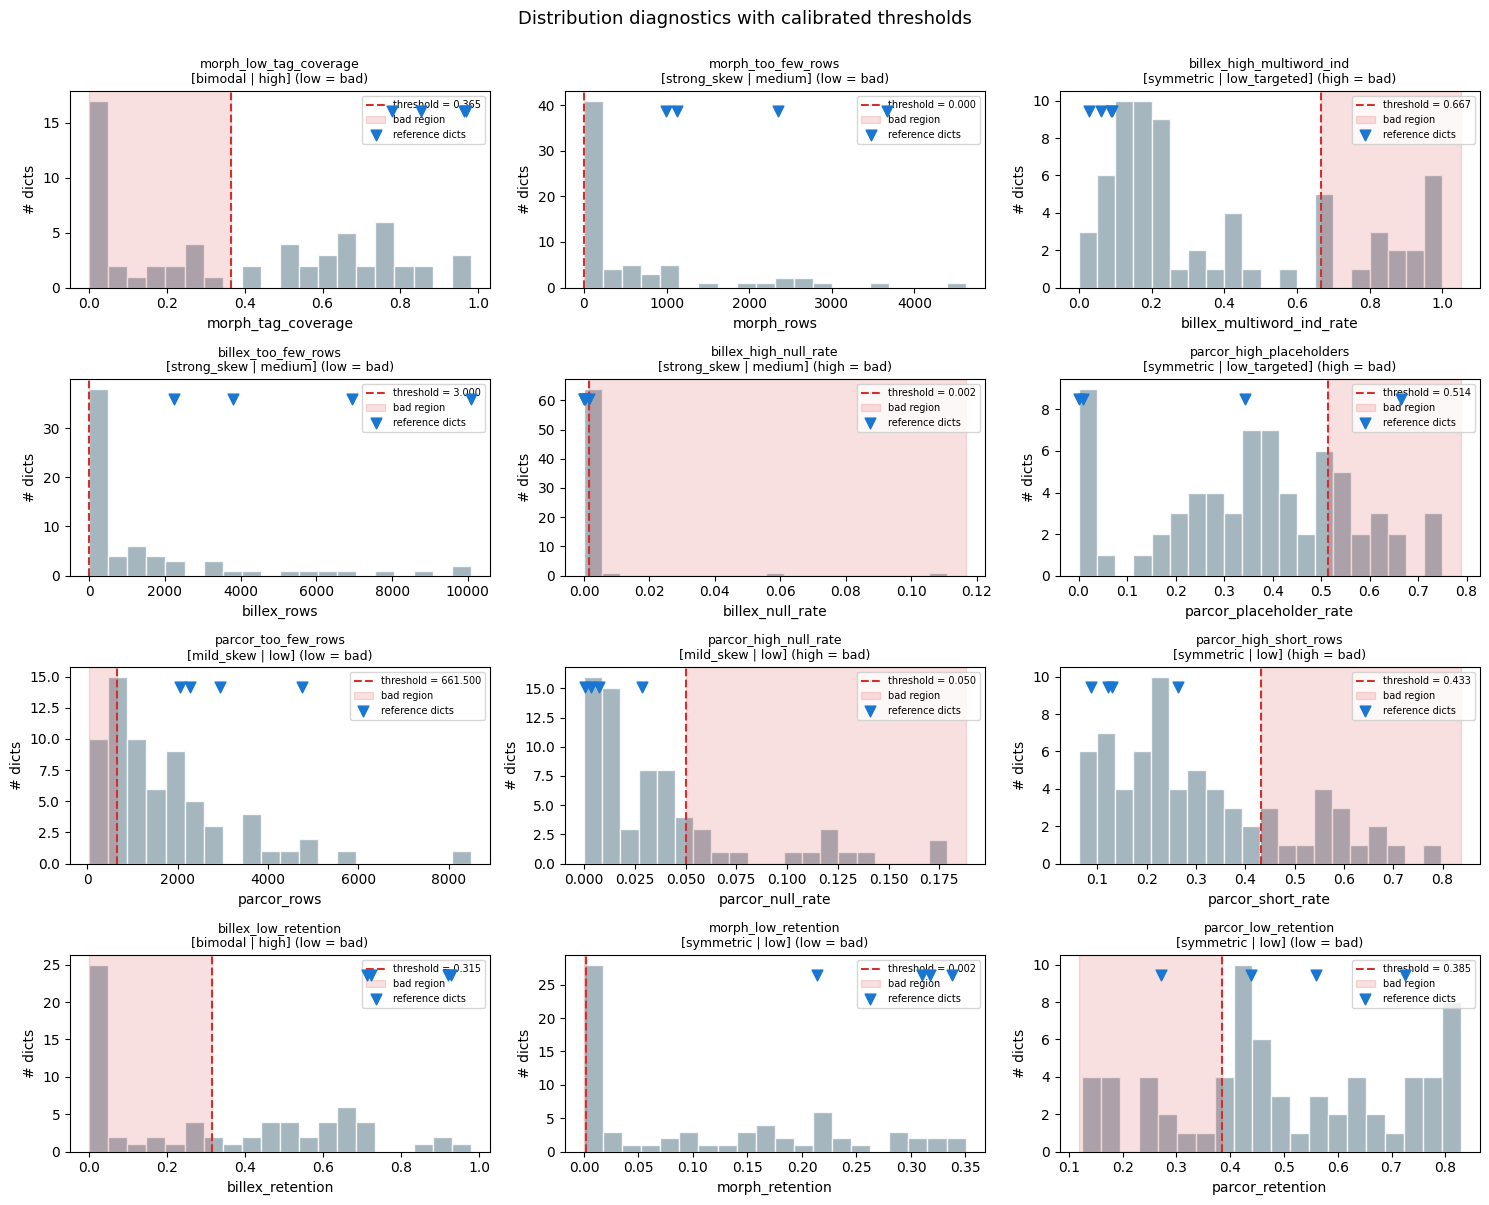

In [17]:
n_metrics = len(METRICS)
n_cols = 3
n_rows = (n_metrics + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

for idx, metric in enumerate(METRICS):
    ax = axes[idx]
    col = metric["column"]
    name = metric["name"]
    direction = metric["direction"]

    if col not in metrics_df.columns:
        ax.text(0.5, 0.5, f"(no data: {col})", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(name, fontsize=10)
        continue

    cal_row = calibration_df[calibration_df["rule_name"] == name].iloc[0]
    threshold = cal_row["threshold"]
    confidence = cal_row["confidence"]
    shape = cal_row["shape"]

    values = metrics_df[col].dropna().values

    # Histogram
    ax.hist(values, bins=20, color="#90a4ae", edgecolor="white", alpha=0.8)

    if threshold is not None:
        # Threshold line
        ax.axvline(threshold, color="#d32f2f", linestyle="--", linewidth=1.5,
                   label=f"threshold = {threshold:.3f}")

        # Shade the "bad" region
        ymin, ymax = ax.get_ylim()
        if direction == "high":
            ax.axvspan(threshold, max(values.max(), threshold) * 1.05,
                       alpha=0.15, color="#d32f2f", label="bad region")
        else:
            ax.axvspan(min(values.min(), threshold) * 0.95, threshold,
                       alpha=0.15, color="#d32f2f", label="bad region")

    # Mark reference dicts
    ref_values = []
    for d in REFERENCE_GOOD_DICTS:
        row = metrics_df[metrics_df["dict_id"] == d]
        if len(row) > 0 and not pd.isna(row[col].iloc[0]):
            ref_values.append(row[col].iloc[0])
    if ref_values:
        ax.scatter(ref_values, [ax.get_ylim()[1] * 0.9] * len(ref_values),
                   color="#1976d2", marker="v", s=60, zorder=10, label="reference dicts")

    title = f"{name}\n[{shape} | {confidence}]"
    if direction == "high":
        title += " (high = bad)"
    else:
        title += " (low = bad)"
    ax.set_title(title, fontsize=9)
    ax.set_xlabel(col)
    ax.set_ylabel("# dicts")
    if threshold is not None:
        ax.legend(fontsize=7, loc="upper right")

# Hide unused axes
for idx in range(len(METRICS), len(axes)):
    axes[idx].axis("off")

plt.suptitle("Distribution diagnostics with calibrated thresholds",
             fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig(DST_DIR / "_distribution_diagnostics.png", dpi=120, bbox_inches="tight")
plt.show()

## 8. Retention vs row-count comparison

For each resource, compare which dicts the absolute row-count rule flags vs.
which the retention rule flags. Three categories:
- Both rules flag — high-confidence broken
- Only row-count flags — small but clean (likely false positive of row-count rule)
- Only retention flags — bad retention but enough rows to pass row-count
- Neither flags — no row-related issue

In [18]:
comparison_rows = []
for resource in ["billex", "morph", "parcor"]:
    rowcount_rule = f"{resource}_too_few_rows"
    retention_rule = f"{resource}_low_retention"

    rc_cal = calibration_df[calibration_df["rule_name"] == rowcount_rule]
    rt_cal = calibration_df[calibration_df["rule_name"] == retention_rule]

    if len(rc_cal) == 0 or len(rt_cal) == 0:
        continue

    rc_thresh = rc_cal["threshold"].iloc[0]
    rt_thresh = rt_cal["threshold"].iloc[0]

    for _, row in metrics_df.iterrows():
        rc_val = row.get(f"{resource}_rows")
        rt_val = row.get(f"{resource}_retention")

        if pd.isna(rc_val):
            rc_flagged = None
        elif rc_thresh is None:
            rc_flagged = None
        else:
            rc_flagged = bool(rc_val < rc_thresh)

        if pd.isna(rt_val):
            rt_flagged = None  # retention not applicable
        elif rt_thresh is None:
            rt_flagged = None
        else:
            rt_flagged = bool(rt_val < rt_thresh)

        if rc_flagged is None or rt_flagged is None:
            category = "n/a (one or both not applicable)"
        elif rc_flagged and rt_flagged:
            category = "both_flagged"
        elif rc_flagged and not rt_flagged:
            category = "rowcount_only"
        elif not rc_flagged and rt_flagged:
            category = "retention_only"
        else:
            category = "neither"

        comparison_rows.append({
            "dict_id": row["dict_id"], "resource": resource,
            "rows": rc_val, "retention": rt_val, "prep_rows": row.get("prep_rows"),
            "rc_threshold": rc_thresh, "rt_threshold": rt_thresh,
            "rc_flagged": rc_flagged, "rt_flagged": rt_flagged,
            "category": category,
        })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(DST_DIR / "_retention_vs_rowcount_comparison.csv", index=False)

# Summary breakdown per resource
print("=== Row-count vs Retention rule comparison ===\n")
for resource in ["billex", "morph", "parcor"]:
    sub = comparison_df[comparison_df["resource"] == resource]
    print(f"--- {resource.upper()} ---")
    breakdown = sub["category"].value_counts()
    for cat in ["both_flagged", "rowcount_only", "retention_only", "neither", "n/a (one or both not applicable)"]:
        print(f"  {cat:<45} {breakdown.get(cat, 0)}")
    print()

=== Row-count vs Retention rule comparison ===

--- BILLEX ---
  both_flagged                                  6
  rowcount_only                                 0
  retention_only                                29
  neither                                       33
  n/a (one or both not applicable)              0

--- MORPH ---
  both_flagged                                  0
  rowcount_only                                 0
  retention_only                                17
  neither                                       51
  n/a (one or both not applicable)              0

--- PARCOR ---
  both_flagged                                  10
  rowcount_only                                 7
  retention_only                                7
  neither                                       44
  n/a (one or both not applicable)              0



### 8.1 Visualization of overlap

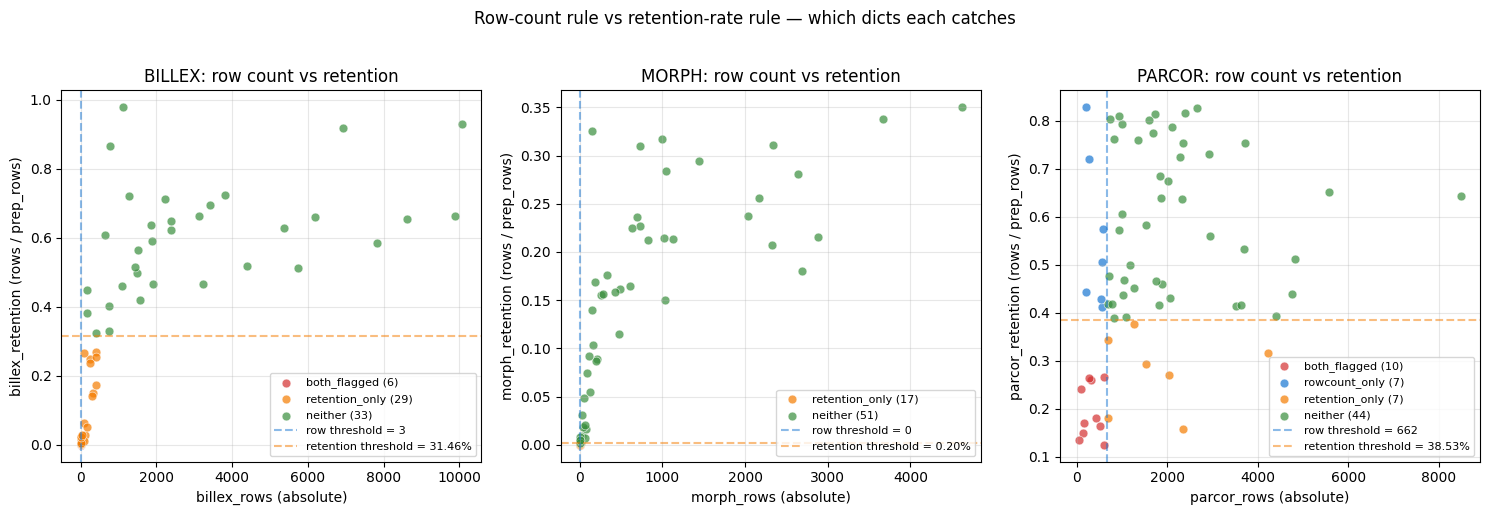

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, resource in zip(axes, ["billex", "morph", "parcor"]):
    sub = comparison_df[comparison_df["resource"] == resource].copy()
    sub = sub[sub["category"] != "n/a (one or both not applicable)"]

    rc_thresh = sub["rc_threshold"].iloc[0] if len(sub) else None
    rt_thresh = sub["rt_threshold"].iloc[0] if len(sub) else None

    if len(sub) == 0 or rc_thresh is None or rt_thresh is None:
        ax.text(0.5, 0.5, f"(rules incomplete for {resource})",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_title(resource.upper())
        continue

    cat_colors = {"both_flagged": "#d32f2f", "rowcount_only": "#1976d2",
                  "retention_only": "#f57c00", "neither": "#388e3c"}
    for cat, color in cat_colors.items():
        cat_data = sub[sub["category"] == cat]
        if len(cat_data) > 0:
            ax.scatter(cat_data["rows"], cat_data["retention"],
                       c=color, label=f"{cat} ({len(cat_data)})", alpha=0.7, s=40,
                       edgecolor="white", linewidth=0.5)

    ax.axvline(rc_thresh, color="#1976d2", linestyle="--", alpha=0.5,
               label=f"row threshold = {rc_thresh:.0f}")
    ax.axhline(rt_thresh, color="#f57c00", linestyle="--", alpha=0.5,
               label=f"retention threshold = {rt_thresh:.2%}")

    ax.set_xlabel(f"{resource}_rows (absolute)")
    ax.set_ylabel(f"{resource}_retention (rows / prep_rows)")
    ax.set_title(f"{resource.upper()}: row count vs retention")
    ax.legend(fontsize=8, loc="best")
    ax.grid(alpha=0.3)

plt.suptitle("Row-count rule vs retention-rate rule — which dicts each catches",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(DST_DIR / "_retention_vs_rowcount_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

## 9. Summary

Re-examine these once you've run the notebook:

1. **Confidence breakdown.** How many rules got high/medium/low/skipped?
   If many rules are low or skipped, the corpus has weak structural signal
   for those rules — investigate whether the metrics themselves are right.
2. **Reference-dict flagged report.** Any reference dict flagged by any
   rule is worth investigating before downstream tier classification.
3. **Retention vs row-count overlap.** Look at the per-resource breakdown:
   - If `rowcount_only` is large: the row-count rule is probably flagging
     small-but-clean dicts (false positives), and retention is more selective
   - If `retention_only` is large: the retention rule is catching dicts the
     row-count rule misses (e.g., large dicts with poor extraction yield)
   - If `both_flagged` dominates: the rules largely agree, retention is
     redundant
4. **Decision on retention.** Based on (3), decide whether to keep the
   retention rules in v3 of the sanity check, replace the row-count rules
   with retention, or keep both as parallel signals.